# **II) MPE Classification — Qwen2.5-7B & Mistral-Nemo**


| column | Ollama model |
|---|---|
| `mpe_qwen` | `qwen2.5:7b-instruct` |
| `mpe_nemo` | `mistral-nemo` |


## 1) Classifications

In [1]:
from ollama import Client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, time

client = Client()

In [2]:
#  models
MODELS = {
    "mpe_qwen": "qwen2.5:7b-instruct",
    "mpe_nemo": "mistral-nemo",
}
GEN_OPTIONS = {"temperature": 0.8, "top_k": 40, "top_p": 0.9}

# Classification
# scores in data/classifications/mpe_qwen.csv and data/classifications/mpe_nemo.csv
RUN_CLASSIFICATION = False

CLASS_DIR  = "data/classifications"
SAVE_EVERY = 1000

system_prompt = """
    Analyze the tweet provided below to determine the stance on monetary policy expressed by the user. Tweets often feature concise language, hashtags, and abbreviations typical of social media communication. Consider the context and the specific wording to classify the stance into one of the following categories: "Very Hawkish", "Hawkish", "Neutral", "Dovish", and "Very Dovish".

    - "Very Hawkish": This category should be selected if the tweet indicates an aggressive stance towards fighting inflation, likely advocating for significant interest rate hikes or other contractionary measures. Look for strong language supporting drastic monetary tightening.
    - "Hawkish": Choose this if the tweet suggests a tendency towards tightening monetary policy to control inflation. It may not indicate extreme measures but shows a clear preference for policy tightening.
    - "Neutral": This applies if the tweet implies a balanced approach, without clear leanings towards tightening or easing monetary policy. It might suggest contentment with maintaining current policy levels or express views that neither strongly support nor oppose policy changes.
    - "Dovish": Select this category if the tweet points towards a preference for easing monetary policy, likely aiming to stimulate economic growth by advocating for lower interest rates or through quantitative easing.
    - "Very Dovish": This should be chosen if the tweet reflects a strong inclination towards stimulating the economy, suggesting substantial measures for easing monetary policy beyond standard adjustments, like a significant push for quantitative easing or deep cuts in interest rates.

    Consider not only the explicit content but also the tone, hashtags, and any economic indicators or events mentioned to understand the user's stance fully. Provide your classification along with a brief explanation of the key factors that influenced your decision.

    Remember, your response should only be a category, nothing more. This task is about classification accuracy, not explanation or detail.
    """

user_prompt = """
    Instructions:
    - Analyze the tweet: "{}"
    - Classify into categories: "Very hawkish," "Hawkish," "Neutral," "Dovish," or "Very dovish.".
    - Do not include any explanations, elaborations, or additional information in your response. Your role is solely to classify, not to explain or discuss, return only the category.
    """

keyword_map = {"neutral": 0, "very hawkish": -2, "hawkish": -1, "dovish": 1, "very dovish": 2}

def classify(text, model, options=GEN_OPTIONS):
    """Classify one tweet with `model`. Returns an int score in [-2, 2] or None."""
    prompt = user_prompt.format(text)
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": prompt},
    ]
    resp = client.chat(model=model, messages=messages, options=options, stream=False)
    result = resp["message"]["content"].strip().lower()

    # 1) exact leading keyword
    for keyword, value in keyword_map.items():
        if result.startswith(keyword):
            return value
    # 2) fall back to substring search (check 'very *' first)
    if "very hawkish" in result:  return -2
    if "very dovish"  in result:  return 2
    if "hawkish"      in result:  return -1
    if "dovish"       in result:  return 1
    if "neutral"      in result:  return 0
    return None

In [3]:
# load the tweets (FED + MACRO)
df_fed   = pd.read_csv("data/stocktwits/FED_class.csv")
df_macro = pd.read_csv("data/stocktwits/MACRO_class.csv")
df = pd.concat([df_fed, df_macro], ignore_index=True)

df["source"] = ["FED"] * len(df_fed) + ["MACRO"] * len(df_macro)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["body"] = df["body"].astype(str)
df = df.reset_index(drop=True)
df["row_key"] = np.arange(len(df))   # stable position key

print(f"{len(df):,} tweets to classify with {len(MODELS)} models")

118,563 tweets to classify with 2 models


In [4]:
os.makedirs(CLASS_DIR, exist_ok=True)

def _run_path(col):
    return os.path.join(CLASS_DIR, f"{col}.csv")

STORED_RUNS_ARE_HAWKISH_POSITIVE = True  

def load_run(frame, col):
    """Merge an existing per-run CSV (if any) into `frame` by row_key.

    Stored scores are converted to the paper's sign convention (Hawkish negative) on load.
    """
    path = _run_path(col)
    if os.path.exists(path):
        prev = pd.read_csv(path)[["row_key", col]]
        if STORED_RUNS_ARE_HAWKISH_POSITIVE:
            prev[col] = -pd.to_numeric(prev[col], errors="coerce")
        frame = frame.drop(columns=[col], errors="ignore").merge(prev, on="row_key", how="left")
    elif col not in frame.columns:
        frame[col] = np.nan
    return frame


def save_run(frame, col):
    """Write a per-run CSV back in the SAME orientation load_run expects, so the on-disk
    files stay self-consistent (load_run negates them again on the next read)."""
    out = frame[["row_key", "id_", col]].copy()
    if STORED_RUNS_ARE_HAWKISH_POSITIVE:
        out[col] = -pd.to_numeric(out[col], errors="coerce")
    out.to_csv(_run_path(col), index=False)


In [5]:
# resumable classification, one isolated CSV per model

for col, tag in MODELS.items():
    df = load_run(df, col)
    todo = df.index[df[col].isna()]
    print(f"{col} ({tag}): {int(df[col].notna().sum()):,} classified, {len(todo)} remaining")
    if RUN_CLASSIFICATION and len(todo):
        t0 = time.time()
        for k, i in enumerate(todo):
            try:
                df.at[i, col] = classify(df.at[i, "body"], tag)
            except Exception as e:
                print(f"  row {i} error: {e}")
            if (k + 1) % SAVE_EVERY == 0:
                save_run(df, col)
                print(f"  {k+1}/{len(todo)}  ({time.time()-t0:,.0f}s)")
        save_run(df, col)

mpe_qwen (qwen2.5:7b-instruct): 118,561 classified, 2 remaining
mpe_nemo (mistral-nemo): 118,563 classified, 0 remaining


In [6]:
# low-temperature run (temperature = 0.3), same prompt & parser, isolated columns
# Near-greedy decoding: reruns the identical prompt framework at temp 0.3 to check how much of the
# tweet-level variation is decoding noise rather than signal
MODELS_T03 = {
    "mpe_qwen_t03": "qwen2.5:7b-instruct",
    "mpe_nemo_t03": "mistral-nemo",
}
GEN_OPTIONS_T03 = {"temperature": 0.3, "top_k": 40, "top_p": 0.9}

# Set to True to run, only fills rows that are still NaN
RUN_CLASSIFICATION_T03 = False

for col, tag in MODELS_T03.items():
    df = load_run(df, col)
    todo = df.index[df[col].isna()]
    print(f"{col} ({tag}, temp=0.3): {int(df[col].notna().sum()):,} classified, {len(todo)} remaining")
    if RUN_CLASSIFICATION_T03 and len(todo):
        t0 = time.time()
        for k, i in enumerate(todo):
            try:
                df.at[i, col] = classify(df.at[i, "body"], tag, options=GEN_OPTIONS_T03)
            except Exception as e:
                print(f"  row {i} error: {e}")
            if (k + 1) % SAVE_EVERY == 0:
                save_run(df, col)
                print(f"  {k+1}/{len(todo)}  ({time.time()-t0:,.0f}s)")
        save_run(df, col)


mpe_qwen_t03 (qwen2.5:7b-instruct, temp=0.3): 118,562 classified, 1 remaining
mpe_nemo_t03 (mistral-nemo, temp=0.3): 118,563 classified, 0 remaining


In [7]:
# weekly engagement-weighted MPE indices
WINSOR_LEVEL = 0.005   # winsorized at the 1% level at construction

def winsorize(series, level=WINSOR_LEVEL):
    """Percentile winsorization: values below the `level` quantile are set to it, values
    above the `1 - level` quantile likewise. Applied to every weekly MPE index the moment
    it is constructed, so all comparisons, plots and saved CSVs use winsorized values."""
    lo, hi = series.quantile(level), series.quantile(1 - level)
    return series.clip(lo, hi)
def weekly_mpe(frame, class_col):
    d = frame.dropna(subset=[class_col, "date"]).copy()
    d["nb_likes"]    = pd.to_numeric(d["nb_likes"], errors="coerce").fillna(0)
    d["nb_reshares"] = pd.to_numeric(d["nb_reshares"], errors="coerce").fillna(0)
    # +1 base weight so posts with 0 engagement aren't deleted from the math
    d["engagement"]  = d["nb_likes"] + d["nb_reshares"] + 1
    d["weighted"]    = pd.to_numeric(d[class_col], errors="coerce") * d["engagement"]
    g = d.resample("W", on="date")
    idx = g["weighted"].sum() / g["engagement"].sum()
    # winsorized at construction
    return winsorize(idx).rename(class_col)

weekly_mpe_index = pd.concat([weekly_mpe(df, c) for c in MODELS], axis=1).reset_index()
weekly_mpe_index.columns = ["date", "mpe_qwen", "mpe_nemo"]
weekly_mpe_index["date"] = weekly_mpe_index["date"].dt.tz_localize(None)

print(weekly_mpe_index.shape)

# the temp-0.3 series are written to their own file so all four runs can be compared
weekly_mpe_t03 = pd.concat([weekly_mpe(df, c) for c in MODELS_T03], axis=1).reset_index()
weekly_mpe_t03.columns = ["date", "mpe_qwen_t03", "mpe_nemo_t03"]
weekly_mpe_t03["date"] = weekly_mpe_t03["date"].dt.tz_localize(None)

weekly_all = weekly_mpe_index.merge(weekly_mpe_t03, on="date", how="outer").sort_values("date")
weekly_all.to_csv("data/weekly_mpe_index_all_runs.csv", index=False)
print("all four runs:", weekly_all.shape, "-> data/weekly_mpe_index_all_runs.csv")

weekly_mpe_index.tail()

(790, 3)
all four runs: (790, 5) -> data/weekly_mpe_index_all_runs.csv


,date,mpe_qwen,mpe_nemo
785,2025-02-02,-0.062176,-0.341969
786,2025-02-09,0.045872,-0.192661
787,2025-02-16,-0.050000,-0.487500
788,2025-02-23,-0.214286,-0.809524
789,2025-03-02,0.000000,0.156385


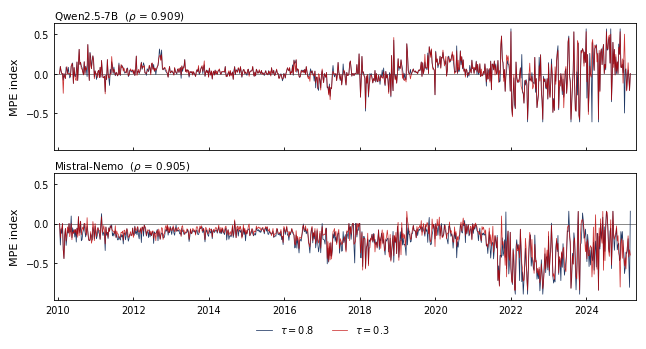

In [8]:
# non engagement-weighted version: simple weekly mean of the tweet classes 
def weekly_mpe_unweighted(frame, class_col):
    d = frame.dropna(subset=[class_col, "date"]).copy()
    # same winsorization at construction as the engagement-weighted index (see section 1)
    return winsorize(d.resample("W", on="date")[class_col].mean()).rename(class_col)

# all four runs at once 
weekly_mpe_unw = pd.concat(
    [weekly_mpe_unweighted(df, c) for c in list(MODELS) + list(MODELS_T03)], axis=1).reset_index()
weekly_mpe_unw.columns = ["date"] + list(MODELS) + list(MODELS_T03)
weekly_mpe_unw["date"] = weekly_mpe_unw["date"].dt.tz_localize(None)

# the weekly engagement-weighted index, each model at both decoding temperatures
PANELS = [("mpe_qwen", "mpe_qwen_t03", "Qwen2.5-7B"),
          ("mpe_nemo", "mpe_nemo_t03", "Mistral-Nemo")]

plt.rcParams.update({
    "font.size":         8,
    "axes.labelsize":    8,
    "axes.titlesize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "axes.linewidth":    0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

fig, axes = plt.subplots(2, 1, figsize=(6.5, 3.4), sharex=True, sharey=True)
for ax, (hi, lo, name) in zip(axes, PANELS):
    ax.plot(weekly_all["date"], weekly_all[hi], lw=0.55, color="#1F3864",
            label=r"$\tau = 0.8$")
    ax.plot(weekly_all["date"], weekly_all[lo], lw=0.55, color="#C00000", alpha=0.8,
            label=r"$\tau = 0.3$")
    ax.axhline(0, color="0.35", lw=0.5, zorder=0)
    ax.set_ylabel("MPE index")
    ax.margins(x=0.01)
    ax.tick_params(direction="in", length=2.5)
    r = weekly_all[hi].corr(weekly_all[lo])
    # panel label above the axes, so it never overlaps the series
    ax.set_title(f"{name}  ($\\rho$ = {r:.3f})", fontsize=7.5, loc="left", pad=2.5)

# one shared legend below the panels, so neither series is overplotted
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           handlelength=1.6, columnspacing=1.8, bbox_to_anchor=(0.5, -0.02))
fig.align_ylabels(axes)
plt.tight_layout(h_pad=0.8, rect=(0, 0.03, 1, 1))
plt.savefig("figures/mpe_index_temperature.pdf", bbox_inches="tight")
plt.show()

plt.rcdefaults()   # restore the default style for the remaining notebook figures

## 2) Comparison — Qwen2.5-7B vs Mistral-Nemo, at both decoding temperatures

Agreement check across **all four runs** (`mpe_qwen`, `mpe_nemo` at temp 0.8 and
`mpe_qwen_t03`, `mpe_nemo_t03` at temp 0.3). 


In [9]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from itertools import combinations

# All four runs: the two temp-0.8 configurations and the two temp-0.3 (low-temperature) ones.
ALL_RUNS = {
    "mpe_qwen":     "Qwen2.5-7B, temp=0.8",
    "mpe_nemo":     "Mistral-Nemo, temp=0.8",
    "mpe_qwen_t03": "Qwen2.5-7B, temp=0.3",
    "mpe_nemo_t03": "Mistral-Nemo, temp=0.3",
}

to3 = lambda s: np.sign(s)            # -1 = Hawkish, 0 = Neutral, +1 = Dovish

def pair_stats(x, y):
    """Per-tweet agreement between two classification runs, on the 3-category scale.
    agreement  : share of tweets given the same DIRECTION by both runs
    pearson    : linear correlation of the two -1/0/+1 direction series
    quad_kappa : Cohen's kappa with quadratic weights over {-1, 0, +1} -- chance-corrected
                 agreement that penalises a disagreement by the SQUARE of the distance
                 between the two classes (Hawkish vs Neutral counts far less than
                 Hawkish vs Dovish)."""
    b = df[[x, y]].dropna()
    p, q = to3(b[x]), to3(b[y])
    return {
        "pair":       f"{x} vs {y}",
        "n":          len(b),
        "agreement":  round((p == q).mean(), 3),
        "pearson":    round(p.corr(q), 3),
        "quad_kappa": round(cohen_kappa_score(p, q, weights="quadratic", labels=[-1, 0, 1]), 3),
    }


# every pairwise combination of the four runs
summary = pd.DataFrame([pair_stats(x, y) for x, y in combinations(ALL_RUNS, 2)]).set_index("pair")
print("Per-tweet agreement, all pairs of runs "
      "(3-category scale: Hawkish / Neutral / Dovish):")
print(summary.to_string())

#  LaTeX: same layout as the other paper tables (table[H], notes as \caption* inside a
# {small} group above the tabular, tabular wrapped in \resizebox)
TEX_RUN = {
    "mpe_qwen":     r"Qwen2.5-7B ($\tau$=0.8)",
    "mpe_nemo":     r"Mistral-Nemo ($\tau$=0.8)",
    "mpe_qwen_t03": r"Qwen2.5-7B ($\tau$=0.3)",
    "mpe_nemo_t03": r"Mistral-Nemo ($\tau$=0.3)",
}

# N varies by a handful of tweets across pairs (a few rows failed to parse in one run
# or another), so the notes report the range rather than a single figure.
n_lo, n_hi = int(summary["n"].min()), int(summary["n"].max())
n_txt = f"{n_lo:,}" if n_lo == n_hi else f"{n_lo:,}--{n_hi:,}"

body = "\n".join(
    "\\textit{" + " vs. ".join(TEX_RUN[p] for p in pair.split(" vs ")) + "} & " +
    " & ".join(f"{summary.loc[pair, k]:.3f}"
               for k in ("agreement", "pearson", "quad_kappa")) + r" \\"
    for pair in summary.index)

latex = rf"""\begin{{table}}[H]
\centering
\caption{{Per-Tweet Agreement Between Classification Runs}}
\label{{tab:mpe_run_agreement}}
\begin{{small}}
\caption*{{\small \textbf{{Notes:}} Each pair of classification runs is compared on the
collapsed three-category scale, in which the two hawkish classes ($-2,-1$) are merged into a
single Hawkish category and the two dovish classes ($+1,+2$) into a single Dovish category,
so that only the DIRECTION of the stance is compared and disagreements about intensity are
ignored. Agree.\ is the share of tweets assigned the same direction by both runs, $r$ the
Pearson correlation of the two $-1/0/+1$ series, and $\kappa_w$ Cohen's kappa with quadratic
weights over $\{{-1,0,+1\}}$. $\tau$ denotes the decoding temperature; each pair is computed on
the tweets classified by both runs ($N$ = {n_txt}).}}
\end{{small}}
\resizebox{{0.99\textwidth}}{{!}}{{%
\begin{{tabular}}{{l ccc}}
\toprule
Pair of runs & Agree. & $r$ & $\kappa_w$ \\
\midrule
{body}
\bottomrule
\end{{tabular}}}}
\end{{table}}"""

print("\n" + latex)

Per-tweet agreement, all pairs of runs (3-category scale: Hawkish / Neutral / Dovish):
                                   n  agreement  pearson  quad_kappa
pair                                                                
mpe_qwen vs mpe_nemo          118561      0.855    0.363       0.336
mpe_qwen vs mpe_qwen_t03      118561      0.990    0.935       0.935
mpe_qwen vs mpe_nemo_t03      118561      0.881    0.394       0.373
mpe_nemo vs mpe_qwen_t03      118562      0.855    0.360       0.334
mpe_nemo vs mpe_nemo_t03      118563      0.918    0.717       0.714
mpe_qwen_t03 vs mpe_nemo_t03  118562      0.881    0.393       0.373

\begin{table}[H]
\centering
\caption{Per-Tweet Agreement Between Classification Runs}
\label{tab:mpe_run_agreement}
\begin{small}
\caption*{\small \textbf{Notes:} Each pair of classification runs is compared on the
collapsed three-category scale, in which the two hawkish classes ($-2,-1$) are merged into a
single Hawkish category and the two dovish classes (

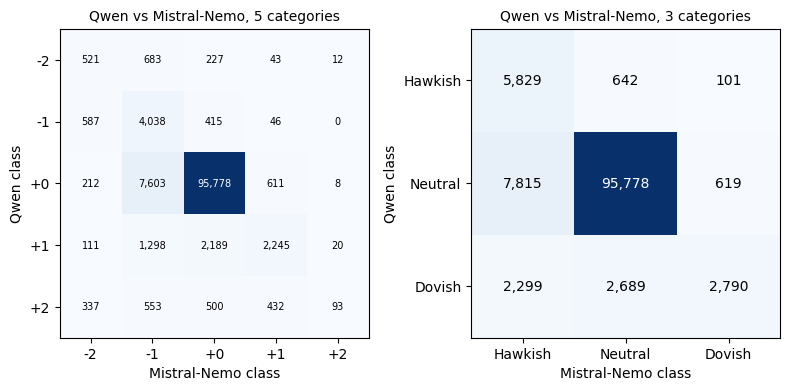

In [10]:
# confusion matrices
X, Y = "mpe_qwen_t03", "mpe_nemo_t03"
b = df[[X, Y]].dropna()

lab5 = [-2, -1, 0, 1, 2]
lab3, name3 = [-1, 0, 1], {-1: "Hawkish", 0: "Neutral", 1: "Dovish"}

panels = [
    (confusion_matrix(b[X], b[Y], labels=lab5), [f"{l:+d}" for l in lab5], "5 categories"),
    (confusion_matrix(np.sign(b[X]), np.sign(b[Y]), labels=lab3),
     [name3[l] for l in lab3], "3 categories"),
]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (cm, ticks, ttl) in zip(axes, panels):
    k = len(ticks)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(k)); ax.set_xticklabels(ticks)
    ax.set_yticks(range(k)); ax.set_yticklabels(ticks)
    ax.set_xlabel("Mistral-Nemo class"); ax.set_ylabel("Qwen class")
    for r in range(k):
        for c in range(k):
            ax.text(c, r, f"{cm[r, c]:,}", ha="center", va="center",
                    fontsize=7 if k == 5 else 10,
                    color="white" if cm[r, c] > cm.max() / 2 else "black")
    ax.set_title(f"Qwen vs Mistral-Nemo, {ttl}", fontsize=10)
plt.tight_layout()
plt.savefig("figures/confusion_matrices.pdf", bbox_inches="tight")
plt.show()

In [11]:
# --- correlation of the weekly engagement-weighted MPE indices, all four runs ---
corr_w = weekly_all[list(ALL_RUNS)].corr().round(3)
print("Weekly MPE index correlation — engagement-weighted:")
print(corr_w.to_string())

# --- LaTeX (booktabs, minimalist academic style) ---
# Lower triangle only: the matrix is symmetric with a unit diagonal, so the upper half is
# blanked out rather than printed twice.
tex_corr = corr_w.copy()
tex_corr.index = tex_corr.columns = [TEX_RUN[c] for c in corr_w.columns]
tex_corr = tex_corr.astype(object)
for r in range(len(tex_corr)):
    for c in range(r + 1, len(tex_corr)):
        tex_corr.iloc[r, c] = ""
tex_corr.index.name = None   # avoids the blank second header row
tex_corr.columns = [f"({i})" for i in range(1, len(tex_corr.columns) + 1)]
tex_corr.index = [f"({i}) {n}" for i, n in enumerate(tex_corr.index, start=1)]

print("\n" + tex_corr.to_latex(
    index=True, column_format="l cccc", float_format="%.3f", escape=False,
    caption="Correlation of the weekly engagement-weighted MPE indices across the four "
            "classification runs. Lower triangle; the matrix is symmetric with a unit diagonal.",
    label="tab:mpe_weekly_corr", position="htbp"))

Weekly MPE index correlation — engagement-weighted:
              mpe_qwen  mpe_nemo  mpe_qwen_t03  mpe_nemo_t03
mpe_qwen         1.000     0.482         0.909         0.485
mpe_nemo         0.482     1.000         0.466         0.905
mpe_qwen_t03     0.909     0.466         1.000         0.447
mpe_nemo_t03     0.485     0.905         0.447         1.000

\begin{table}[htbp]
\caption{Correlation of the weekly engagement-weighted MPE indices across the four classification runs. Lower triangle; the matrix is symmetric with a unit diagonal.}
\label{tab:mpe_weekly_corr}
\begin{tabular}{l cccc}
\toprule
 & (1) & (2) & (3) & (4) \\
\midrule
(1) Qwen2.5-7B ($\tau$=0.8) & 1.000 &  &  &  \\
(2) Mistral-Nemo ($\tau$=0.8) & 0.482 & 1.000 &  &  \\
(3) Qwen2.5-7B ($\tau$=0.3) & 0.909 & 0.466 & 1.000 &  \\
(4) Mistral-Nemo ($\tau$=0.3) & 0.485 & 0.905 & 0.447 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}



## 3) Manual validation — ~1,100 blind human labels

Two stratified samples were hand-labeled **blind** on the same five-category scale
(built by `TEMP/build_validation_qwen_nemo.py`: per model, disjoint samples of 100 neutral +
100 directional tweets each, shuffled and stripped of all model information), then
**reconciled** into one final set of manual classes:

| workbook | rows | stratified on |
|---|---|---|
| `data/manual_validations/MPE_manual_reconciled.xlsx` | 1,100 | `mpe_qwen_t03` + `mpe_nemo_t03` |


In [12]:
# load the RECONCILED manual labels and map each labeled tweet back to the corpus
# MPE_manual_reconciled.xlsx is the FINAL manual classification.
VAL_FILE = "data/manual_validations/MPE_manual_reconciled.xlsx"

manual_map = {"Very Hawkish": -2, "Hawkish": -1, "Neutral": 0, "Dovish": 1, "Very Dovish": 2}

ann = pd.read_excel(VAL_FILE, sheet_name="Comparison")
ann["manual"] = ann["Label"].map(manual_map)
ann = ann.rename(columns={"Conf": "Manual_Confidence"})

# the *_full.csv sample records written by TEMP/build_validation_qwen_nemo.py carry the corpus
# row_key of every sampled tweet; the workbook rows are matched back on (Source, Tweet)
rec = pd.concat([pd.read_csv(f"data/validation_qwen_nemo/{tag}_{l}_full.csv")
                 for tag in ("qwen", "nemo") for l in "ABC"], ignore_index=True)
rec = rec[["source", "body", "row_key"]].drop_duplicates(["source", "body"])

val = ann.merge(rec, left_on=["Source", "Tweet"], right_on=["source", "body"], how="left")
print(f"reconciled workbook: {len(ann):,} rows, {int(ann['manual'].notna().sum()):,} labeled, "
      f"{int(val['row_key'].notna().sum()):,} matched to the corpus")
val = val[["row_key", "manual", "Manual_Confidence"]].dropna(subset=["row_key", "manual"])

dup = val[val["row_key"].duplicated(keep=False)]
if len(dup):
    same = dup.groupby("row_key")["manual"].nunique().eq(1).mean()
    print(f"labeled twice: {dup['row_key'].nunique()} tweets "
          f"(labels identical for {same:.0%} of them) -> kept once")
val_pooled = (val.drop_duplicates("row_key")
                 .merge(df[["row_key"] + list(ALL_RUNS)], on="row_key", how="left"))
print(f"pooled validation set: {len(val_pooled):,} tweets")

print("\nManual label distribution (reconciled):")
lab_names = {-2: "Very Hawkish", -1: "Hawkish", 0: "Neutral", 1: "Dovish", 2: "Very Dovish"}
print(val_pooled["manual"].map(lab_names).value_counts().to_string())

reconciled workbook: 1,100 rows, 1,100 labeled, 1,100 matched to the corpus
labeled twice: 5 tweets (labels identical for 100% of them) -> kept once
pooled validation set: 1,095 tweets

Manual label distribution (reconciled):
manual
Neutral         615
Dovish          211
Hawkish         174
Very Dovish      81
Very Hawkish     14


All four runs vs the reconciled 1,095 human labels:
              agreement  pearson  quad_kappa
model                                       
mpe_qwen          0.644    0.488       0.477
mpe_nemo          0.611    0.403       0.364
mpe_qwen_t03      0.645    0.493       0.480
mpe_nemo_t03      0.625    0.463       0.431


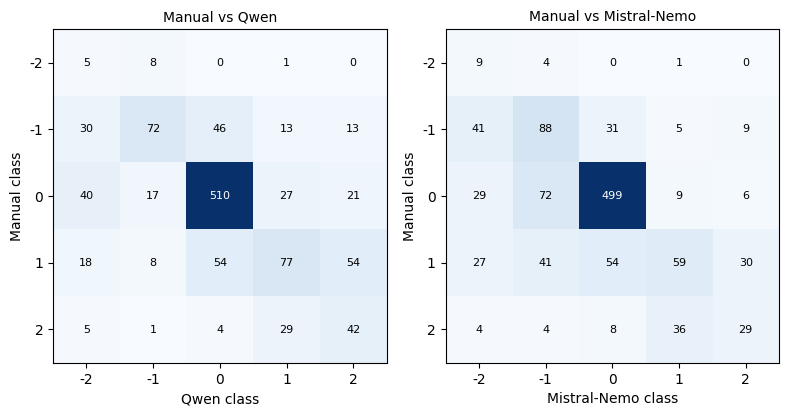

In [13]:
def vs_manual(frame, col):
    """One run against the reconciled human labels: exact agreement, linear correlation of the
    -2..+2 classes, and quadratic-weighted kappa (chance-corrected, distance-penalised)."""
    m = frame.dropna(subset=["manual", col])
    return {
        "model":      col,
        "agreement":  round((m["manual"] == m[col]).mean(), 3),
        "pearson":    round(m["manual"].corr(m[col]), 3),
        "quad_kappa": round(cohen_kappa_score(m["manual"], m[col], weights="quadratic"), 3),
    }

# all four runs against the same reconciled human labels
res = pd.DataFrame([vs_manual(val_pooled, c) for c in ALL_RUNS]).set_index("model")
print(f"All four runs vs the reconciled {len(val_pooled):,} human labels:")
print(res.to_string())

# confusion matrices for the two low-temperature runs (the configurations the samples audit)
labels = [-2, -1, 0, 1, 2]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col, name in zip(axes, ["mpe_qwen_t03", "mpe_nemo_t03"], ["Qwen", "Mistral-Nemo"]):
    b = val_pooled.dropna(subset=["manual", col])
    cm = confusion_matrix(b["manual"], b[col], labels=labels)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(5)); ax.set_xticklabels(labels)
    ax.set_yticks(range(5)); ax.set_yticklabels(labels)
    ax.set_xlabel(f"{name} class"); ax.set_ylabel("Manual class")
    for r in range(5):
        for c in range(5):
            ax.text(c, r, cm[r, c], ha="center", va="center", fontsize=8,
                    color="white" if cm[r, c] > cm.max() / 2 else "black")
    ax.set_title(f"Manual vs {name}", fontsize=10)
plt.tight_layout()
plt.savefig("figures/confusion_manual.pdf", bbox_inches="tight")
plt.show()

Three-category comparison vs the reconciled human labels (right panel drops Neutral on both sides):
             All tweets (H/N/D)                              Directional only (H/D)                             
                              n agreement pearson quad_kappa                      n agreement pearson quad_kappa
model                                                                                                           
mpe_qwen                   1095     0.757   0.534      0.534                    371     0.846   0.675      0.675
mpe_nemo                   1095     0.696   0.399      0.369                    368     0.728   0.521      0.478
mpe_qwen_t03               1095     0.755   0.531      0.530                    376     0.843   0.669      0.668
mpe_nemo_t03               1095     0.726   0.456      0.432                    387     0.765   0.568      0.541

\begin{table}[H]
\centering
\caption{Agreement with the Reconciled Manual Labels, Three-Category Scale}
\lab

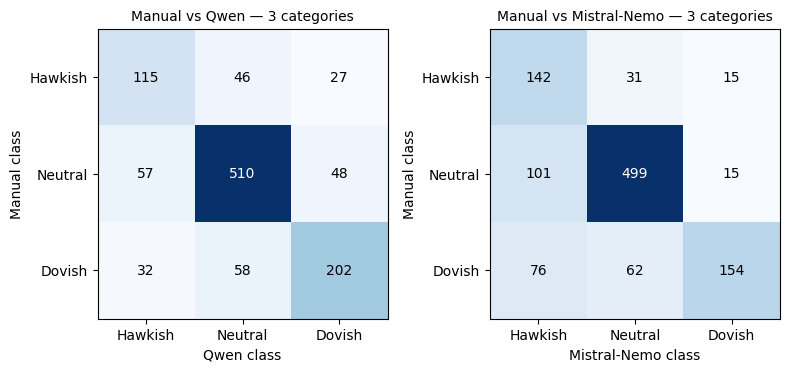

In [14]:
# --- 3-category comparison: Hawkish (-2,-1) / Neutral (0) / Dovish (+1,+2) ---
# Collapsing the two hawkish and the two dovish categories removes the intensity dimension

to3 = lambda s: np.sign(s)            # -1 = Hawkish, 0 = Neutral, +1 = Dovish
lab3 = [-1, 0, 1]
name3 = {-1: "Hawkish", 0: "Neutral", 1: "Dovish"}

rows_all, rows_dir = [], []
for col in ALL_RUNS:
    m = val_pooled.dropna(subset=["manual", col])
    y, p = to3(m["manual"]), to3(m[col])
    rows_all.append({
        "model":      col,
        "n":          len(m),
        "agreement":  round((y == p).mean(), 3),
        "pearson":    round(y.corr(p), 3),
        "quad_kappa": round(cohen_kappa_score(y, p, weights="quadratic"), 3),
    })
    k = (y != 0) & (p != 0)                       # both sides directional
    yd, pd_ = y[k], p[k]
    rows_dir.append({
        "model":      col,
        "n":          int(k.sum()),
        "agreement":  round((yd == pd_).mean(), 3),
        "pearson":    round(yd.corr(pd_), 3),
        "quad_kappa": round(cohen_kappa_score(yd, pd_, weights="quadratic", labels=[-1, 1]), 3),
    })

res3     = pd.DataFrame(rows_all).set_index("model")
res3_dir = pd.DataFrame(rows_dir).set_index("model")

# the two panels side by side, one printed object
res3_both = pd.concat({"All tweets (H/N/D)": res3,
                       "Directional only (H/D)": res3_dir}, axis=1)
print("Three-category comparison vs the reconciled human labels "
      "(right panel drops Neutral on both sides):")
print(res3_both.to_string())

# LaTeX: one minimalist booktabs table, the two panels side by side
TABLE_RUNS = ["mpe_qwen_t03", "mpe_nemo_t03"]
PRETTY = {"mpe_qwen_t03": "Qwen2.5-7B", "mpe_nemo_t03": "Mistral-Nemo"}
COLS = ["agreement", "pearson", "quad_kappa"]
HEAD = r"Agree. & $r$ & $\kappa_w$"

body = "\n".join(
    f"\\textit{{{PRETTY[c]}}} & " +
    " & ".join(f"{res3.loc[c, k]:.3f}" for k in COLS) +
    " & " +
    " & ".join(f"{res3_dir.loc[c, k]:.3f}" for k in COLS) +
    r" \\"
    for c in TABLE_RUNS)

# N reported in the notes instead of in columns: constant in (A), model-specific in (B)
n_all = int(res3.loc[TABLE_RUNS[0], "n"])
n_dir = ", ".join(f"{PRETTY[c]} {int(res3_dir.loc[c, 'n']):,}" for c in TABLE_RUNS)

latex = rf"""\begin{{table}}[H]
\centering
\caption{{Agreement with the Reconciled Manual Labels, Three-Category Scale}}
\label{{tab:mpe_manual_3cat}}
\begin{{small}}
\caption*{{\small \textbf{{Notes:}} Model classes and human labels are collapsed to
Hawkish ($-2,-1$), Neutral ($0$) and Dovish ($+1,+2$). Panel (A) uses every labeled tweet
($N = {n_all:,}$); panel (B) keeps only the tweets that both the annotator and the model called
directional, so that agreeing on ``no direction'' contributes nothing to the score
($N$ = {n_dir}). Agree.\ is the share of exactly matching classes, $r$ the Pearson correlation,
and $\kappa_w$ Cohen's kappa with quadratic weights (over $\{{-1,0,+1\}}$ in panel A and
$\{{-1,+1\}}$ in panel B).}}
\end{{small}}
\resizebox{{0.99\textwidth}}{{!}}{{%
\begin{{tabular}}{{l ccc ccc}}
\toprule
& \multicolumn{{3}}{{c}}{{(A) All tweets: Hawkish / Neutral / Dovish}}
& \multicolumn{{3}}{{c}}{{(B) Directional only: Hawkish / Dovish}} \\
\cmidrule(lr){{2-4}} \cmidrule(lr){{5-7}}
Model & {HEAD} & {HEAD} \\
\midrule
{body}
\bottomrule
\end{{tabular}}}}
\end{{table}}"""

print("\n" + latex)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col, name in zip(axes, ["mpe_qwen_t03", "mpe_nemo_t03"], ["Qwen", "Mistral-Nemo"]):
    b = val_pooled.dropna(subset=["manual", col])
    cm = confusion_matrix(to3(b["manual"]), to3(b[col]), labels=lab3)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels([name3[l] for l in lab3])
    ax.set_yticks(range(3)); ax.set_yticklabels([name3[l] for l in lab3])
    ax.set_xlabel(f"{name} class"); ax.set_ylabel("Manual class")
    for r in range(3):
        for c in range(3):
            ax.text(c, r, cm[r, c], ha="center", va="center", fontsize=10,
                    color="white" if cm[r, c] > cm.max() / 2 else "black")
    ax.set_title(f"Manual vs {name} — 3 categories", fontsize=10)
plt.tight_layout()
plt.savefig("figures/confusion_manual_3cat.pdf", bbox_inches="tight")
plt.show()

## 4) Are the neutrals really neutral? — relevance triage and the final index

**The critique.** The MPE index averages over *all* messages with `Neutral = 0`, and ~85% of the
corpus is neutral. But "neutral" mixes two very different things:

| kind | example | monetary-policy information? |
|---|---|---|
| **real neutral** — on-topic, no direction | *"FOMC meets Wednesday, consensus is a hold."* | **yes** — a genuine "no change" expectation, belongs in the index at 0 |
| **off-topic neutral** — not about monetary policy | *"$MACRO oil inventories build again."* | **no** — never a policy expectation, pure dilution |

In [15]:
# prompt: is this neutral tweet about monetary policy at all? 

CONFIGS = {
    "mpe_qwen":     "qwen2.5:7b-instruct",
    "mpe_nemo":     "mistral-nemo",
    "mpe_qwen_t03": "qwen2.5:7b-instruct",
    "mpe_nemo_t03": "mistral-nemo",
}
# short model tag -> ollama model, used for the per-model triage files
REL_MODELS = {
    "qwen": "qwen2.5:7b-instruct",
    "nemo": "mistral-nemo",
}
# which triage file each configuration reads
CONFIG_REL = {
    "mpe_qwen": "qwen", "mpe_qwen_t03": "qwen",
    "mpe_nemo": "nemo", "mpe_nemo_t03": "nemo",
}

GEN_OPTIONS_REL = {"temperature": 0.3, "top_k": 40, "top_p": 0.9}

relevance_system_prompt = """
    You are given a message posted on a financial social media platform. The message has already
    been judged not to express any directional view on monetary policy — it is neither hawkish nor dovish.

    Your only task is to decide whether the message is ABOUT monetary policy at all. Classify it into
    exactly one of the following two categories:

    - "Related": The message concerns monetary policy or the institutions and instruments that set it.
      This includes the Federal Reserve, the FOMC, its members and their communications, interest
      rates and rate decisions, quantitative easing or tightening, the money supply, the policy
      response to inflation, or the future path of policy. The message may simply report, question,
      or comment on these topics without taking any side — that still counts as "Related".

    - "Unrelated": The message does not concern monetary policy. This includes messages about
      individual stocks or crypto prices, company earnings, commodities, geopolitics, fiscal or tax
      policy, general market moves, promotional content, jokes, insults, or content with no economic
      meaning at all. Mentioning an economic figure in passing, with no link to policy, is "Unrelated".

    Judge only the topic, not the opinion. Do not consider whether the message is hawkish or dovish;
    that question has already been answered and is not being asked again.

    Remember, your response must be only one of the two category names, nothing more.
    """

relevance_user_prompt = """
    Instructions:
    - Analyze the message: "{}"
    - Classify into exactly one category: "Related" or "Unrelated".
    - "Related" means the message is about monetary policy, the Federal Reserve, or interest rates,
      even if it expresses no opinion on their direction.
    - "Unrelated" means the message is about something else entirely.
    - Do not include any explanations, elaborations, or additional information in your response.
      Your role is solely to classify, not to explain or discuss, return only the category.
    """


def classify_relevance(text, model, options=GEN_OPTIONS_REL):
    """1 = about monetary policy, 0 = not about monetary policy, None = unparseable."""
    messages = [
        {"role": "system", "content": relevance_system_prompt},
        {"role": "user",   "content": relevance_user_prompt.format(text)},
    ]
    resp = client.chat(model=model, messages=messages, options=options, stream=False)
    result = resp["message"]["content"].strip().lower()

    # 1) exact leading keyword — check the longer 'unrelated' first, since 'related' is a substring of it
    if result.startswith("unrelated"): return 0
    if result.startswith("related"):   return 1
    # 2) fall back to substring search (same precedence)
    if "unrelated" in result:  return 0
    if "not related" in result: return 0
    if "related" in result:    return 1
    return None


print("relevance triage configured for:")
for col, tag in CONFIGS.items():
    print(f"  {col:14s} -> {tag} (triage file: rel_{CONFIG_REL[col]}.csv)")

relevance triage configured for:
  mpe_qwen       -> qwen2.5:7b-instruct (triage file: rel_qwen.csv)
  mpe_nemo       -> mistral-nemo (triage file: rel_nemo.csv)
  mpe_qwen_t03   -> qwen2.5:7b-instruct (triage file: rel_qwen.csv)
  mpe_nemo_t03   -> mistral-nemo (triage file: rel_nemo.csv)


In [16]:
# select the remaining neutrals in each configuration

neutral_keys = {col: set(df.loc[df[col] == 0, "row_key"]) for col in CONFIGS}

print("Neutral class per configuration:")
for col in CONFIGS:
    n = len(neutral_keys[col])
    print(f"  {col:14s} {n:>7,} neutral  ({n / df[col].notna().sum():6.2%} of classified)")

# union of neutrals per model = the set actually sent to the LLM
rel_todo_keys = {
    tag: set().union(*[neutral_keys[col] for col in CONFIGS if CONFIG_REL[col] == tag])
    for tag in REL_MODELS
}

print("\nTriage workload (union per model, reused across its two temperature runs):")
total_calls = 0
for tag, keys in rel_todo_keys.items():
    cols = [c for c in CONFIGS if CONFIG_REL[c] == tag]
    print(f"  {tag:5s} {len(keys):>7,} unique neutrals  <- {' + '.join(cols)}")
    total_calls += len(keys)
naive = sum(len(v) for v in neutral_keys.values())
print(f"\n  total calls  : {total_calls:,}")
print(f"  naive (4x)   : {naive:,}   -> saving {1 - total_calls / naive:.1%}")

Neutral class per configuration:
  mpe_qwen       104,210 neutral  (87.90% of classified)
  mpe_nemo        96,081 neutral  (81.04% of classified)
  mpe_qwen_t03   104,212 neutral  (87.90% of classified)
  mpe_nemo_t03    99,109 neutral  (83.59% of classified)

Triage workload (union per model, reused across its two temperature runs):
  qwen  104,653 unique neutrals  <- mpe_qwen + mpe_qwen_t03
  nemo  102,265 unique neutrals  <- mpe_nemo + mpe_nemo_t03

  total calls  : 206,918
  naive (4x)   : 403,612   -> saving 48.7%


In [17]:
# resumable relevance triage, one isolated CSV per model

RUN_RELEVANCE = True

def _rel_path(tag):
    return os.path.join(CLASS_DIR, f"rel_{tag}.csv")


def load_rel(tag):
    """Existing triage results for `tag` as a row_key -> {0,1} Series (empty if never run)."""
    path = _rel_path(tag)
    if os.path.exists(path):
        prev = pd.read_csv(path)
        return prev.set_index("row_key")[f"rel_{tag}"].dropna()
    return pd.Series(dtype="float64", name=f"rel_{tag}")


def save_rel(tag, series):
    (series.rename(f"rel_{tag}").rename_axis("row_key").reset_index()
        .to_csv(_rel_path(tag), index=False))


body_by_key = df.set_index("row_key")["body"]
rel_scores = {}

for tag, model in REL_MODELS.items():
    done = load_rel(tag)
    todo = sorted(rel_todo_keys[tag] - set(done.index))
    print(f"rel_{tag} ({model}): {len(done):,} triaged, {len(todo):,} remaining")

    if RUN_RELEVANCE and todo:
        t0 = time.time()
        for k, key in enumerate(todo):
            try:
                done.at[key] = classify_relevance(body_by_key.at[key], model)
            except Exception as e:
                print(f"  row_key {key} error: {e}")
            if (k + 1) % SAVE_EVERY == 0:
                save_rel(tag, done)
                rate = (k + 1) / max(time.time() - t0, 1e-9)
                eta = (len(todo) - k - 1) / max(rate, 1e-9) / 60
                print(f"  {k+1:,}/{len(todo):,}  ({time.time()-t0:,.0f}s, {rate:.1f}/s, ETA {eta:,.0f} min)")
        save_rel(tag, done)
        print(f"  done in {(time.time()-t0)/60:,.1f} min")

    rel_scores[tag] = done.dropna()

# attach one relevance column per configuration (NaN for tweets that configuration did not call neutral)
for col in CONFIGS:
    src = rel_scores[CONFIG_REL[col]]
    mapped = df["row_key"].map(src)
    df[f"rel_{col}"] = mapped.where(df[col] == 0)     # only defined on that config's neutrals

print("\nCoverage of the triage (share of each configuration's neutrals with a relevance label):")
for col in CONFIGS:
    have, need = df[f"rel_{col}"].notna().sum(), len(neutral_keys[col])
    print(f"  {col:14s} {have:>7,} / {need:>7,}  ({have / need:6.2%})" if need else f"  {col}: no neutrals")

rel_qwen (qwen2.5:7b-instruct): 104,653 triaged, 0 remaining
rel_nemo (mistral-nemo): 102,265 triaged, 0 remaining

Coverage of the triage (share of each configuration's neutrals with a relevance label):
  mpe_qwen       104,210 / 104,210  (100.00%)
  mpe_nemo        96,081 /  96,081  (100.00%)
  mpe_qwen_t03   104,212 / 104,212  (100.00%)
  mpe_nemo_t03    99,109 /  99,109  (100.00%)


In [18]:
# what is actually inside the Neutral class?
#   real neutral : about monetary policy, no direction -> KEPT at 0 in the corrected index
#   off-topic    : not about monetary policy at all    -> DROPPED from the corrected index

CMP_CONFIGS = ["mpe_qwen_t03"]     # the final-index configuration (Qwen, temp 0.3)

rows = []
for col in CMP_CONFIGS:
    n_tot = int(df[col].notna().sum())
    lab = df.loc[df[col] == 0, f"rel_{col}"].dropna()        # 1 = real neutral, 0 = off-topic
    rows.append({
        "run":              col,
        "classified":       n_tot,
        "directional":      int(((df[col] != 0) & df[col].notna()).sum()),   # NaN != 0 is True
        "neutral":          int((df[col] == 0).sum()),
        "neutral share":    f"{(df[col] == 0).sum() / n_tot:.1%}",
        "real neutral":     int((lab == 1).sum()),
        "off-topic":        int((lab == 0).sum()),
        "off-topic share":  f"{(lab == 0).mean():.1%}" if len(lab) else "—",
    })
print("Composition of the Neutral class (temp-0.3 runs):")
print(pd.DataFrame(rows).set_index("run").to_string())



Composition of the Neutral class (temp-0.3 runs):
              classified  directional  neutral neutral share  real neutral  off-topic off-topic share
run                                                                                                  
mpe_qwen_t03      118562        14350   104212         87.9%         41716      62496           60.0%



mpe_qwen_t03 — full sample, Neutral split into real vs not MPE-related:


,Obs,Share (%),Likes,Reshares,Avg. Engag.
Very Hawkish (-2),1486,1.25,0.907133,0.045087,0.952221
Hawkish (-1),5086,4.29,0.724931,0.058396,0.783327
"Neutral (0, real)",41716,35.18,0.319518,0.025841,0.345359
Dovish (+1),5863,4.95,0.560464,0.038376,0.598840
Very Dovish (+2),1915,1.62,0.794778,0.044386,0.839164
Not MPE-related,62496,52.71,0.217614,0.016097,0.233711
TOTAL / Average,118562,100.00,0.310150,0.023262,0.333412


\begin{table}[H]
\centering
\caption{Descriptive Statistics of the MPE Index}
\label{tab:mpe_summary_stats_mpe_qwen_t03}
\begin{small}
\caption*{\small \textbf{Notes:} This table summarizes the 118,562 messages classified
from the \$FED and \$MACRO StockTwits messages (2014--2025). Categories represent the stance
toward monetary policy: Very Hawkish ($-2$), Hawkish ($-1$), Neutral ($0$), Dovish ($+1$) and
Very Dovish ($+2$). The Neutral class is further split by a second, binary relevance prompt:
messages that concern monetary policy without expressing a direction are reported as
\textit{Neutral ($0$, MPE-related)} and are retained in the index at zero, whereas messages
that do not concern monetary policy at all are reported as \textit{Not MPE-related} and are
excluded from it. The corrected index is therefore built on the 56,066 directional
and MPE-related messages. \textit{Share (\%)} represents the percentage of total messages in
each category; \textit{Avg. Likes} and \textit{Avg. R

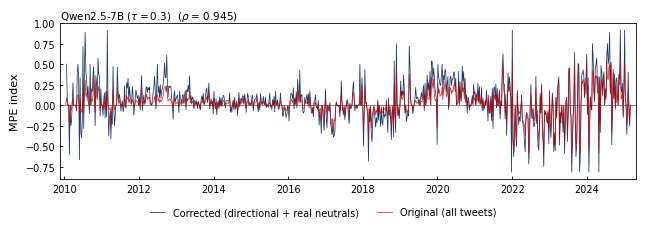

In [19]:
# the corrected index: directional tweets + real neutrals kept at 0
def real_sample(col):
    d = df.dropna(subset=[col, "date"])
    return d[(d[col] != 0) | (d[f"rel_{col}"] == 1)]

def dir_sample(col):
    d = df.dropna(subset=[col, "date"])
    return d[d[col] != 0]

# (a) class / engagement table, same format as 03_MPE_Analysis, on the FULL classified
# sample, with the Neutral class split by the relevance triage of 4.3 into:
#   Neutral (0, real)  : about monetary policy, no direction -> kept at 0 in the corrected index
#   Not MPE-related    : never a policy expectation          -> excluded from the corrected index
mapping = {-2: "Very Hawkish (-2)", -1: "Hawkish (-1)", 0: "Neutral (0, real)",
           1: "Dovish (+1)", 2: "Very Dovish (+2)"}
ORDER = [mapping[c] for c in (-2, -1, 0, 1, 2)] + ["Not MPE-related"]

def class_table(d, col):
    d = d.copy()
    d["nb_likes"] = pd.to_numeric(d["nb_likes"], errors="coerce").fillna(0)
    d["nb_reshares"] = pd.to_numeric(d["nb_reshares"], errors="coerce").fillna(0)
    d["Stance"] = d[col].map(mapping)
    d.loc[(d[col] == 0) & (d[f"rel_{col}"] == 0), "Stance"] = "Not MPE-related"
    t = d.groupby("Stance").agg(
        Obs=("id_", "count"),
        Likes=("nb_likes", "mean"),
        Reshares=("nb_reshares", "mean"),
    ).reindex(ORDER)
    t["Share (%)"] = (t["Obs"] / len(d) * 100).round(2)
    t["Avg. Engag."] = t["Likes"] + t["Reshares"]
    total = pd.DataFrame({
        "Obs": [len(d)],
        "Likes": [d["nb_likes"].mean()],
        "Reshares": [d["nb_reshares"].mean()],
        "Share (%)": [100.00],
        "Avg. Engag.": [d["nb_likes"].mean() + d["nb_reshares"].mean()],
    }, index=["TOTAL / Average"])
    return pd.concat([t, total])[["Obs", "Share (%)", "Likes", "Reshares", "Avg. Engag."]]

# LaTeX in the same layout as the other paper tables: table[H], notes as a \caption*
def class_table_latex(t, col):
    ROW_TEX = {
        "Very Hawkish (-2)":  r"Very Hawkish ($-2$)",
        "Hawkish (-1)":       r"Hawkish ($-1$)",
        "Neutral (0, real)":  r"Neutral ($0$, MPE-related)",
        "Dovish (+1)":        r"Dovish ($+1$)",
        "Very Dovish (+2)":   r"Very Dovish ($+2$)",
        "Not MPE-related":    r"Not MPE-related",
        "TOTAL / Average":    r"TOTAL / Average",
    }
    body = []
    for name, r in t.iterrows():
        if name == "TOTAL / Average":
            body.append(r"\midrule")
        body.append(
            f"\\textit{{{ROW_TEX.get(name, name)}}} & {int(r['Obs']):,} & "
            f"{r['Share (%)']:.2f} & {r['Likes']:.2f} & {r['Reshares']:.2f} & "
            f"{r['Avg. Engag.']:.2f} \\\\")
    body = "\n".join(body)

    n_tot  = int(t.loc["TOTAL / Average", "Obs"])
    n_off  = int(t.loc["Not MPE-related", "Obs"])
    n_real = int(t.loc["Neutral (0, real)", "Obs"])
    n_dir  = n_tot - n_off - n_real

    return rf"""\begin{{table}}[H]
\centering
\caption{{Descriptive Statistics of the MPE Index}}
\label{{tab:mpe_summary_stats_{col}}}
\begin{{small}}
\caption*{{\small \textbf{{Notes:}} This table summarizes the {n_tot:,} messages classified
from the \$FED and \$MACRO StockTwits messages (2014--2025). Categories represent the stance
toward monetary policy: Very Hawkish ($-2$), Hawkish ($-1$), Neutral ($0$), Dovish ($+1$) and
Very Dovish ($+2$). The Neutral class is further split by a second, binary relevance prompt:
messages that concern monetary policy without expressing a direction are reported as
\textit{{Neutral ($0$, MPE-related)}} and are retained in the index at zero, whereas messages
that do not concern monetary policy at all are reported as \textit{{Not MPE-related}} and are
excluded from it. The corrected index is therefore built on the {n_dir + n_real:,} directional
and MPE-related messages. \textit{{Share (\%)}} represents the percentage of total messages in
each category; \textit{{Avg. Likes}} and \textit{{Avg. Reshares}} denote the mean number of
likes and reshares received per message, respectively; and \textit{{Avg. Engag.}} (Average
Engagement) is defined as the sum of mean likes and reshares per message.}}
\end{{small}}
\resizebox{{0.99\textwidth}}{{!}}{{%
\begin{{tabular}}{{l r r c c c}}
\toprule
& Obs. ($N$) & Share (\%) & Avg. Likes & Avg. Reshares & Avg. Engag. \\
\midrule
{body}
\bottomrule
\end{{tabular}}}}
\end{{table}}"""


for col in CMP_CONFIGS:
    tbl = class_table(df.dropna(subset=[col]), col)
    print(f"\n{col} — full sample, Neutral split into real vs not MPE-related:")
    display(tbl)
    print(class_table_latex(tbl, col))

# (b) weekly index: original vs corrected (same engagement-weighted formula as section 1)
weekly_cmp = pd.concat(
    [weekly_mpe(df, c).rename(f"{c}_all") for c in CMP_CONFIGS]
    + [weekly_mpe(real_sample(c), c).rename(f"{c}_real") for c in CMP_CONFIGS]
    + [weekly_mpe(dir_sample(c), c).rename(f"{c}_dir") for c in CMP_CONFIGS],
    axis=1).reset_index()
weekly_cmp["date"] = weekly_cmp["date"].dt.tz_localize(None)
weekly_cmp.to_csv("data/weekly_mpe_index_relevance.csv", index=False)
print(f"\nsaved data/weekly_mpe_index_relevance.csv  {weekly_cmp.shape}")

cmp = pd.DataFrame([{
    "run":              c,
    "corr(all,real)":   round(weekly_cmp[f"{c}_all"].corr(weekly_cmp[f"{c}_real"]), 3),
    "spearman":         round(weekly_cmp[f"{c}_all"].corr(weekly_cmp[f"{c}_real"], method="spearman"), 3),
    "sd dir":           round(weekly_cmp[f"{c}_dir"].std(), 3),
    "sd real":          round(weekly_cmp[f"{c}_real"].std(), 3),
    "sd all":           round(weekly_cmp[f"{c}_all"].std(), 3),
    "sign agreement":   round((np.sign(weekly_cmp[f"{c}_all"]) == np.sign(weekly_cmp[f"{c}_real"])).mean(), 3),
} for c in CMP_CONFIGS]).set_index("run")
print("\nWeekly index by sample (sd dir >> sd real: the real neutrals at 0 damp the index;"
      "\nsd all < sd real only because 'all' keeps the off-topic zeros as extra dilution):")
print(cmp.to_string())

# plot only the qwen run (the final-index configuration)
# Same paper style as the temperature figure in section 1: 6.5in wide, in-pointing ticks,
c = "mpe_qwen_t03"

plt.rcParams.update({
    "font.size":         8,
    "axes.labelsize":    8,
    "axes.titlesize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "axes.linewidth":    0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

fig, ax = plt.subplots(figsize=(6.5, 2.2))

ax.plot(weekly_cmp["date"], weekly_cmp[f"{c}_real"], lw=0.55, color="#1F3864",
        label="Corrected (directional + real neutrals)")
ax.plot(weekly_cmp["date"], weekly_cmp[f"{c}_all"], lw=0.55, color="#C00000", alpha=0.8,
        label="Original (all tweets)")
ax.axhline(0, color="0.35", lw=0.5, zorder=0)
ax.set_ylabel("MPE index")
ax.margins(x=0.01)
ax.tick_params(direction="in", length=2.5)
r = weekly_cmp[f"{c}_all"].corr(weekly_cmp[f"{c}_real"])
# panel label above the axes, so it never overlaps the series
ax.set_title(f"Qwen2.5-7B ($\\tau = 0.3$)  ($\\rho$ = {r:.3f})",
             fontsize=7.5, loc="left", pad=2.5)

# one shared legend below the panel, so neither series is overplotted
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False,
           handlelength=1.6, columnspacing=1.8, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.savefig("figures/mpe_index_relevance_correction.pdf", bbox_inches="tight")
plt.show()

plt.rcdefaults()   # restore the default style for the remaining notebook figures


saved data/weekly_mpe_index.csv  (788, 2)  (mpe_index = mpe_qwen_t03, variant 'real', winsorized at the 0.5% level (per tail) at construction)


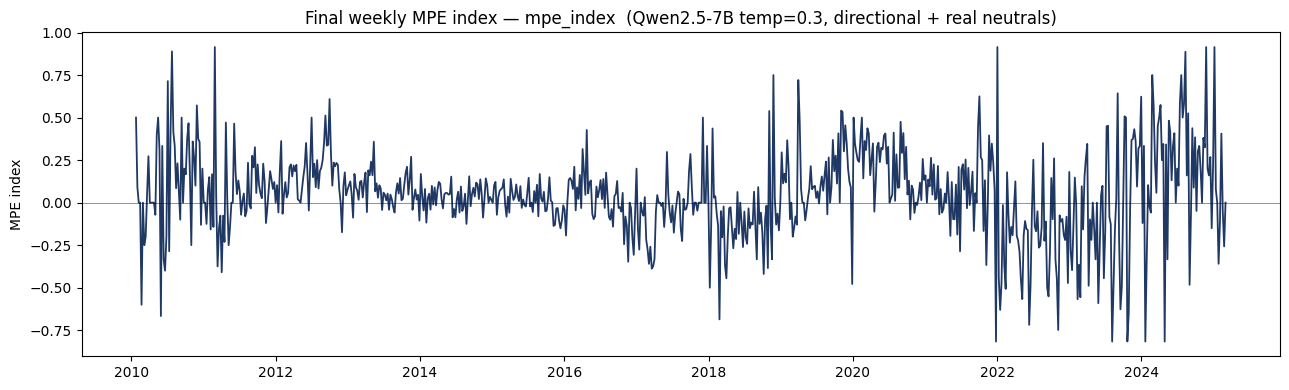

In [20]:
# the final MPE index -> data/weekly_mpe_index.csv 
FINAL_CONFIG, FINAL_VARIANT = "mpe_qwen_t03", "real"   # switch to "all" to keep every neutral

mpe_final = (weekly_cmp[["date", f"{FINAL_CONFIG}_{FINAL_VARIANT}"]]
             .rename(columns={f"{FINAL_CONFIG}_{FINAL_VARIANT}": "mpe_index"})
             .dropna(subset=["mpe_index"]))

mpe_final.to_csv("data/weekly_mpe_index.csv", index=False)
print(f"saved data/weekly_mpe_index.csv  {mpe_final.shape}  "
      f"(mpe_index = {FINAL_CONFIG}, variant '{FINAL_VARIANT}', "
      f"winsorized at the {WINSOR_LEVEL:.1%} level (per tail) at construction)")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mpe_final["date"], mpe_final["mpe_index"], lw=1.3, color="#1F3864")
ax.axhline(0, color="k", lw=0.6, alpha=0.5)
ax.set_title("Final weekly MPE index — mpe_index  "
             "(Qwen2.5-7B temp=0.3, directional + real neutrals)")
ax.set_ylabel("MPE index")
plt.tight_layout()
plt.show()

